In [1]:
import sys
import os


possible_roots = [
    "/workspaces/EV-Torque-Vectoring/src",
    os.path.abspath(os.path.join(os.getcwd(), "src")),
    os.path.abspath(os.path.join(os.getcwd(), "../src")),
    os.path.abspath(os.path.join(os.getcwd(), "../../src"))
]

added = False
for p in possible_roots:
    if os.path.exists(p):
        if p not in sys.path:
            sys.path.insert(0, p) # Put it at the beginning
        print(f"found and added: {p}")
        added = True
        break

if not added:
    print("❌ Could not find 'src'. Please run !pwd and !ls -R to find your folder.")

found and added: /workspaces/EV-Torque-Vectoring/src


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from tv_sim.tv_sim.core.utils.config import VehicleConfig
from tv_sim.tv_sim.core.models.ev_18dof import Vehicle18DOF  
from tv_sim.tv_sim.core.controllers.torque_allocator import TorqueAllocator
from tv_sim.tv_sim.core.controllers.drive_intent import ReferenceModel


In [3]:
from tv_sim.tv_sim.core.models.tire_model import IndependentTire

import numpy as np
def ramp_input(time_array, start_time, end_time, start_val, end_val):
    """
    Creates a smooth linear transition between two values over time.
    """
    out = np.full_like(time_array, start_val)
    mask = (time_array >= start_time) & (time_array <= end_time)
    
    # Linear interpolation
    if end_time > start_time:
        fraction = (time_array[mask] - start_time) / (end_time - start_time)
        out[mask] = start_val + (end_val - start_val) * fraction
        
    # Hold the final value after end_time
    out[time_array > end_time] = end_val
    return out

def trapezoidal_input(time_array, t_start, t_rise, t_fall, t_end, peak_val):
    """
    Useful for throttle: Smoothly ramps up, holds, and ramps down.
    """
    # Rise
    val = ramp_input(time_array, t_start, t_rise, 0.0, peak_val)
    # Fall (overwrites the hold value)
    mask_fall = time_array > t_fall
    val[mask_fall] = ramp_input(time_array[mask_fall], t_fall, t_end, peak_val, 0.0)
    return val



In [ ]:

def run_simulation(cfg, throttle_profile, steer_profile, T_MAX=60.0, DT=0.002, controller_dt=0.05):
    """
    Simulates the 18-DOF vehicle dynamics with internal sub-stepping 
    for tire stability.
    """
    
    steps = int(T_MAX / DT)
    time_array = np.linspace(0, T_MAX, steps)
    
    vehicle = Vehicle18DOF(cfg) 
    reference = ReferenceModel(cfg)
    torque_allocator = TorqueAllocator(cfg)
    
    history = []
    last_execution_controller = -controller_dt 
    mz_request = 0.0

    print(f"Starting reliable simulation: {T_MAX}s, DT={DT}...")

    for i in range(steps):
        t = time_array[i]
        delta = steer_profile[i]
        throttle_request = throttle_profile[i]
        
        # State extraction
        vx = vehicle.state[0]
        actual_yaw_rate = vehicle.state[2]
        target_yaw = reference.get_target_yaw_rate(vx, delta)
        # --- A. CONTROL LAYER ---
        if (t - last_execution_controller) >= (controller_dt - 1e-9):
            
            
            # Placeholder for controller 
      
            last_execution_controller = t
            
        # ALLOCATION LAYER 
        torques = torque_allocator.distribute(throttle_request, mz_request, DT,vx)
        
        #PHYSICS LAYER
        state = vehicle.step(torques, delta, DT,references=True)

        
        # logs
        beta = np.arctan2(state[1], max(state[0], 0.1))
        
        # 38 Columns: [0:34 States + wheel states and dynamics (friction and slips) , 18: Delta, 19: Beta, 20: Mz_req]
        record = np.zeros(42)
        record[0:34] = state #[vx, vy, r, x, y, psi, w1..4, zx1..4, zy1..4,Ffrx_1..4(x friction),Ffry1..4 (y friction),Vrx1..4(slip speed wheel x),vry1..4(slip speed wheel y)]
        record[34]   = beta
        record[35]   = mz_request
        record[36]  =   target_yaw
        record[37]   = delta
        record[38:42] = torques
        
        history.append(record)

    return time_array, np.array(history)

In [ ]:
import numpy as np
import pandas as pd

def extract_sim_data(history, cfg, maneuver_id):
    """
    Inputs:
    - history: (steps, 38) array
    - cfg: VehicleConfig containing Re, Iw, etc.
    """
    steps = history.shape[0]
    DT = 0.002
    tire_records = []

    # Calculate observed wheel acceleration (w_dot)
    # Indices 6-9 are omegas (w1..w4)
    omegas = history[:, 6:10]
    dot_omegas = np.gradient(omegas, DT, axis=0)
    for i in range(1, steps):
        for wheel_idx in range(4):
        
            # Map indices exactly as defined in your record
            record = {
                'maneuver_id': maneuver_id,
                'tire_id': wheel_idx,
                'time': i * DT,
                
                # --- SENSOR INPUTS ---
                'v_slip_x': history[i, 26 + wheel_idx], # Vrx1..4
                'v_slip_y': history[i, 30 + wheel_idx], # Vry1..4
                'omega': history[i, 6 + wheel_idx],     # w1..4
                'w_dot_obs': dot_omegas[i, wheel_idx],
                'w_dot_star': history[i,wheel_idx+38]/cfg.Iw,
                'torque':history[i,wheel_idx+38],
                'delta':history[i,37],
                'chasis x':history[i,3],
                'chasis y':history[i,4],

               
                
                # --- GROUND TRUTH ---
                'F_fx_true': history[i, 18 + wheel_idx], # Ffrx1..4
                'F_fy_true': history[i, 22 + wheel_idx], # Ffry1..4
                'zx_true': history[i, 10 + wheel_idx],   # zx1..4
                'zy_true': history[i, 14 + wheel_idx],   # zy1..4
                
                # --- GLOBAL PARAMETERS ---
                'v_s_true': cfg.vs,
                'mu_k_true': cfg.mu_k,
                'mu_s_true': cfg.mu_s,
                'sigma_0x':  cfg.sigma0[0],
                'sigma_0y':  cfg.sigma0[1],
                'sigma_1x':  cfg.sigma1[0],
                'sigma_1y':  cfg.sigma1[1],
            }
            tire_records.append(record)
            
    return pd.DataFrame(tire_records)

In [ ]:
import numpy as np
import pandas as pd
import time
def generate_full_vehicle_dataset(num_maneuvers=10):
    all_tire_records = []
    
    T_MAX = 10.0
    DT = 0.002
    steps = int(T_MAX / DT)
    time = np.linspace(0, T_MAX, steps)

    for m_id in range(num_maneuvers):
        # --- 1. RANDOMIZE ENVIRONMENT ---
        cfg = VehicleConfig()
        cfg.mu_k = np.random.uniform(0.3, 0.85)
        cfg.mu_s = cfg.mu_k + np.random.uniform(0.1, 0.25)

        cfg.vs = np.random.uniform(1.0, 4.5)
        cfg.sigma0=np.random.uniform(0.9, 1)*cfg.sigma0
        cfg.sigma1=np.random.uniform(0.9, 1)*cfg.sigma1
      
        # Random Throttle: Start/Peak/End times randomized
        t_start = np.random.uniform(0, 0.15)*T_MAX
        t_peak = t_start + np.random.uniform(0.2, 0.6)*T_MAX
        p_val = np.random.uniform(0.2, 0.8)
        throttle_profile = trapezoidal_input(time, t_start, t_start+0.5, t_peak, t_peak+0.5, p_val)

        t_start_brake = np.random.uniform(t_peak, T_MAX * 0.9)
        t_end_brake = min(t_start_brake*(1+np.random.uniform(0.05,0.2)), T_MAX)
        p_val_brake = np.random.uniform(0.1, 0.5)  # Usually higher intensity for testing friction spikes

        brake_profile = trapezoidal_input(
            time, 
            t_start_brake, 
            t_start_brake + 0.4, # Rise time
            t_end_brake - 0.4,   # Start of fall
            t_end_brake,         # End of fall
            p_val_brake
        )
        throttle_profile=throttle_profile-brake_profile

        
        # Random Steering
        steer_freq = np.random.uniform(0.1, 0.5)
        steer_amp = np.radians(np.random.uniform(2, 12))
        steer_profile = steer_amp * np.sin(2 * np.pi * steer_freq * time)
        # Apply a mask so steering doesn't start immediately
        steer_profile[time < 2.0] = 0.0


        print(f"Maneuver {m_id}: Starting (mu_k={cfg.mu_k:.2f}, vs={cfg.vs:.2f})")
        
        _, history = run_simulation(cfg, throttle_profile, steer_profile, T_MAX=T_MAX, DT=DT)

    

        sim_data=extract_sim_data(history,cfg,m_id)
        all_tire_records.append(sim_data)

    return pd.concat(all_tire_records)#history

dataset = generate_full_vehicle_dataset(num_maneuvers=100)

dataset.to_csv(f"../docs/mission_profiles_friction_dataset_{time.asctime()}.csv")

Maneuver 0: Starting (mu_k=0.63, vs=4.37)
Starting reliable simulation: 10.0s, DT=0.002...
Maneuver 1: Starting (mu_k=0.56, vs=4.00)
Starting reliable simulation: 10.0s, DT=0.002...
Maneuver 2: Starting (mu_k=0.31, vs=2.34)
Starting reliable simulation: 10.0s, DT=0.002...
Maneuver 3: Starting (mu_k=0.46, vs=2.29)
Starting reliable simulation: 10.0s, DT=0.002...
Maneuver 4: Starting (mu_k=0.34, vs=3.93)
Starting reliable simulation: 10.0s, DT=0.002...
Maneuver 5: Starting (mu_k=0.62, vs=3.55)
Starting reliable simulation: 10.0s, DT=0.002...
Maneuver 6: Starting (mu_k=0.53, vs=1.81)
Starting reliable simulation: 10.0s, DT=0.002...
Maneuver 7: Starting (mu_k=0.47, vs=3.03)
Starting reliable simulation: 10.0s, DT=0.002...
Maneuver 8: Starting (mu_k=0.47, vs=1.07)
Starting reliable simulation: 10.0s, DT=0.002...
Maneuver 9: Starting (mu_k=0.56, vs=1.00)
Starting reliable simulation: 10.0s, DT=0.002...
Maneuver 10: Starting (mu_k=0.74, vs=1.74)
Starting reliable simulation: 10.0s, DT=0.002..

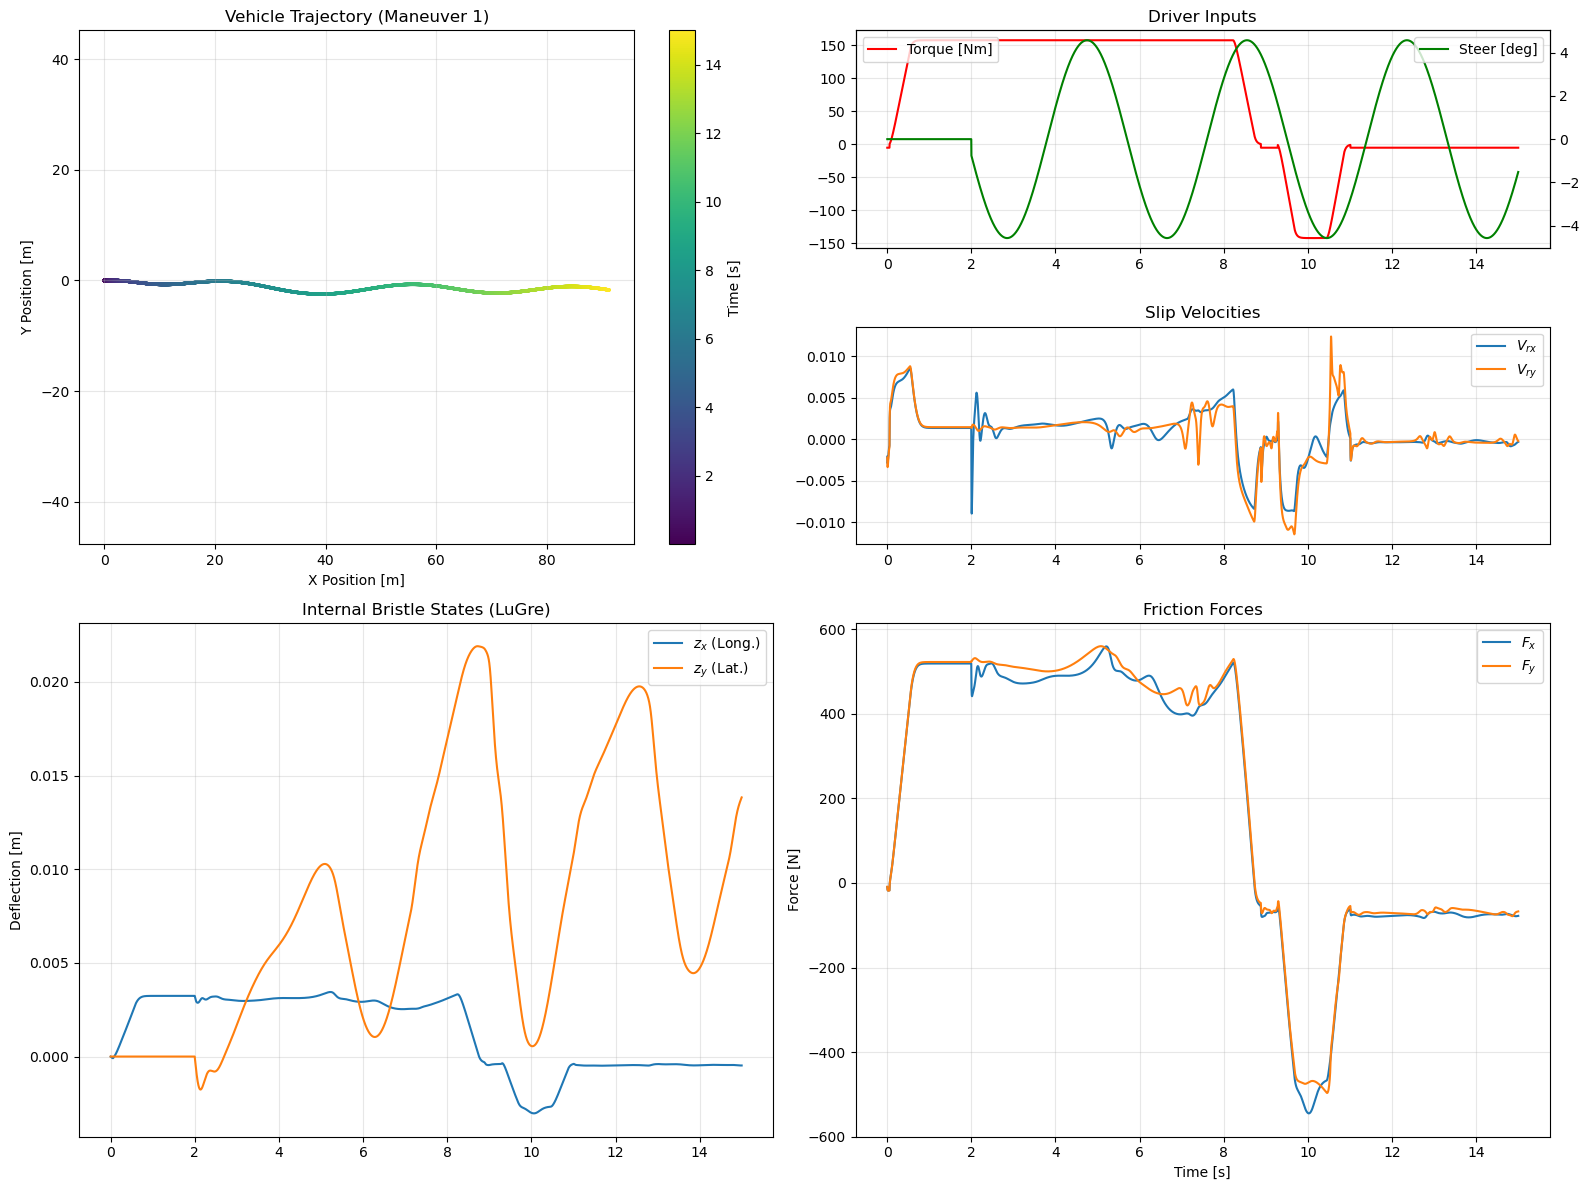

In [18]:
import matplotlib.pyplot as plt
import numpy as np

def plot_maneuver_analysis(df, maneuver_id, tire_id):
    """
    Plots the vehicle trajectory and the detailed tire dynamics.
    """
    # 1. Filter Data
    # For trajectory, we only need the unique chassis positions for the maneuver
    m_data = df[df['maneuver_id'] == maneuver_id].copy()
    # For tire dynamics, we filter by the specific tire
    t_data = m_data[m_data['tire_id'] == tire_id].copy()
    
    if t_data.empty:
        print(f"No data for Maneuver {maneuver_id}, Tire {tire_id}")
        return

    # Assuming you have 'chasis y' in your DF. 
    # If it's named differently, adjust here:
    pos_x = t_data['chasis x'].values
    pos_y = t_data.get('chasis y', np.zeros_like(pos_x)) # Fallback if Y is missing
    t = t_data['time'].values
    
    # 2. Setup Figure Layout (1 Trajectory Plot + 4 Dynamic Plots)
    fig = plt.figure(figsize=(16, 12))
    gs = fig.add_gridspec(4, 2)
    
    # --- Trajectory Plot (Top Left, Spanning 2 rows) ---
    ax_traj = fig.add_subplot(gs[0:2, 0])
    sc = ax_traj.scatter(pos_x, pos_y, c=t, cmap='viridis', s=2)
    ax_traj.set_title(f"Vehicle Trajectory (Maneuver {maneuver_id})")
    ax_traj.set_xlabel("X Position [m]")
    ax_traj.set_ylabel("Y Position [m]")
    ax_traj.axis('equal')
    plt.colorbar(sc, ax=ax_traj, label='Time [s]')
    ax_traj.grid(True, alpha=0.3)

    # --- Inputs: Torque & Steer (Top Right) ---
    ax_in = fig.add_subplot(gs[0, 1])
    ax_in.plot(t, t_data['torque'], 'r', label='Torque [Nm]')
    ax_in_t = ax_in.twinx()
    ax_in_t.plot(t, np.degrees(t_data['delta']), 'g', label='Steer [deg]')
    ax_in.set_title("Driver Inputs")
    ax_in.legend(loc='upper left')
    ax_in_t.legend(loc='upper right')
    ax_in.grid(True, alpha=0.3)

    # --- Slip: Vrx & Vry (Middle Right) ---
    ax_slip = fig.add_subplot(gs[1, 1], sharex=ax_in)
    ax_slip.plot(t, t_data['v_slip_x'], label='$V_{rx}$')
    ax_slip.plot(t, t_data['v_slip_y'], label='$V_{ry}$')
    ax_slip.set_title("Slip Velocities")
    ax_slip.legend()
    ax_slip.grid(True, alpha=0.3)

    # --- States: zx & zy (Bottom Left) ---
    ax_z = fig.add_subplot(gs[2:4, 0], sharex=ax_in)
    ax_z.plot(t, t_data['zx_true'], label='$z_x$ (Long.)')
    ax_z.plot(t, t_data['zy_true'], label='$z_y$ (Lat.)')
    ax_z.set_title("Internal Bristle States (LuGre)")
    ax_z.set_ylabel("Deflection [m]")
    ax_z.legend()
    ax_z.grid(True, alpha=0.3)

    # --- Forces: Fx & Fy (Bottom Right) ---
    ax_f = fig.add_subplot(gs[2:4, 1], sharex=ax_in)
    ax_f.plot(t, t_data['F_fx_true'], label='$F_x$')
    ax_f.plot(t, t_data['F_fy_true'], label='$F_y$')
    ax_f.set_title("Friction Forces")
    ax_f.set_ylabel("Force [N]")
    ax_f.set_xlabel("Time [s]")
    ax_f.legend()
    ax_f.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_maneuver_analysis(dataset, maneuver_id=1, tire_id=0)